Sveučilište u Zagrebu  
Fakultet elektrotehnike i računarstva  
  
## Strojno učenje 1 2025./2026.  
http://www.fer.unizg.hr/predmet/struce1

------------------------------

### Prva laboratorijska vježba: Linearna regresija

*Verzija: 1.0
Zadnji put ažurirano: 1. 10. 2021.*

(c) 2015-2026 Jan Šnajder, Domagoj Alagić 

------------------------------

### Pravila predaje
Predajom vježbe potvrđujete sljedeće točke:
1. Niste od drugoga primili pomoć pri rješavanju vježbe;
2. Atribuirali ste dijelove koda koji su preuzeti s interneta referencirajući ih u komentarima;
3. Niste koristili dijelove koda s interneta koji su specifični za laboratorijsku vježbu;
4. Niste koristili UI-asistente za kodiranje kao npr. GitHub Copilot (uključivo alate generativne UI, kao što je ChatGPT).

**Povreda bilo kojeg od gornjih pravila smatra se prekršajem te povlači akademske sankcije.**

### Upute

Prva laboratorijska vježba sastoji se od sedam zadataka. U nastavku slijedite upute navedene u ćelijama s tekstom. Rješavanje vježbe svodi se na **dopunjavanje ove bilježnice**: umetanja ćelije ili više njih **ispod** teksta zadatka, pisanja odgovarajućeg kôda te evaluiranja ćelija. 

Osigurajte da u potpunosti **razumijete** kôd koji ste napisali. Kod predaje vježbe, morate biti u stanju na zahtjev asistenta (ili demonstratora) preinačiti i ponovno evaluirati Vaš kôd. Nadalje, morate razumjeti teorijske osnove onoga što radite, u okvirima onoga što smo obradili na predavanju. Ispod nekih zadataka možete naći i pitanja koja služe kao smjernice za bolje razumijevanje gradiva (**nemojte pisati** odgovore na pitanja u bilježnicu). Stoga se nemojte ograničiti samo na to da riješite zadatak, nego slobodno eksperimentirajte. To upravo i jest svrha ovih vježbi.

Vježbe trebate raditi **samostalno**. Možete se konzultirati s drugima o načelnom načinu rješavanja, ali u konačnici morate sami odraditi vježbu. U protivnome vježba nema smisla.

In [1]:
from cProfile import label
from functools import reduce

# Učitaj osnovne biblioteke...
import numpy as np
import sklearn
import matplotlib.pyplot as plt
# %pylab inline

### 1. Jednostavna regresija

Zadan je skup primjera $\mathcal{D}=\{(x^{(i)},y^{(i)})\}_{i=1}^4 = \{(0,4),(1,1),(2,2),(4,5)\}$. Primjere predstavite matricom $\mathbf{X}$ dimenzija $N\times n$ (u ovom slučaju $4\times 1$) i vektorom oznaka $\textbf{y}$, dimenzija $N\times 1$ (u ovom slučaju $4\times 1$), na sljedeći način:


In [2]:
X = np.array([[0],[1],[2],[4]])
y = np.array([4,1,2,5])
print(X)

[[0]
 [1]
 [2]
 [4]]


### (a)

Proučite funkciju [`PolynomialFeatures`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) iz biblioteke `sklearn` i upotrijebite je za generiranje matrice dizajna $\mathbf{\Phi}$ koja ne koristi preslikavanje u prostor više dimenzije (samo će svakom primjeru biti dodane *dummy* jedinice; $m=n+1$).


In [3]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5, include_bias=True, interaction_only=False, order="C")
print(poly) # zapravo Polynomialfeatures vraca objekt koji mozemo koristiti za tranformaciju ulazne matrcie dizajna X
# prov je potrebno fitati transformer objekt (poly) sto znaic da se odredi: 1. broj ulaznih znacajki
# 2. i da se odrede sve kombinacije i potencije koji ce se koristiti
# i tek kada fitamo naš transformer na podatke koje ce transformirati, tek ih onda mozemo transformirati sa Transform
poly.fit(X) # sada kada smo fitali imamo razlicite atribute koje mozemo koristiti
print("broj ulaznih znacajki:", poly.n_features_in_)
print("broj novih transformiranih znacajki", poly.n_output_features_)
print("Transformirane znacajke su, zapravo vektor baznih funkcija preslikavanja:", poly.get_feature_names_out(input_features=["x1"]))
# jednom kada smo fitali transformer onda mozemo i transformirat ulazne podatke, tj matricu dizajna X
poly.transform(X)
# poly nam na neki nacin zapravo predstavlja nasu Vektorsku funkciju preslikavnja Theta(ulzani vekotr X) = [1, theta1(vektor primjera x nekog redka), theta2()...]

PolynomialFeatures(degree=5)
broj ulaznih znacajki: 1
broj novih transformiranih znacajki 6
Transformirane znacajke su, zapravo vektor baznih funkcija preslikavanja: ['1' 'x1' 'x1^2' 'x1^3' 'x1^4' 'x1^5']


array([[1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 1.600e+01, 3.200e+01],
       [1.000e+00, 4.000e+00, 1.600e+01, 6.400e+01, 2.560e+02, 1.024e+03]])

In [4]:
# sada zapravo sa funkcijom poly.fit_transform odmah mozemo i fitait transforme robjekt podaicma i transformirati podatke
poly = PolynomialFeatures(degree=1, include_bias=True)
theta = poly.fit_transform(X)
theta

array([[1., 0.],
       [1., 1.],
       [1., 2.],
       [1., 4.]])

### (b)

Upoznajte se s modulom [`linalg`](http://docs.scipy.org/doc/numpy/reference/routines.linalg.html). Izračunajte težine $\mathbf{w}$ modela linearne regresije kao $\mathbf{w}=(\mathbf{\Phi}^\intercal\mathbf{\Phi})^{-1}\mathbf{\Phi}^\intercal\mathbf{y}$. Zatim se uvjerite da isti rezultat možete dobiti izračunom pseudoinverza $\mathbf{\Phi}^+$ matrice dizajna, tj. $\mathbf{w}=\mathbf{\Phi}^+\mathbf{y}$, korištenjem funkcije [`pinv`](http://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.pinv.html).

In [5]:
from numpy import linalg
w = np.linalg.inv(theta.T @ theta) @ theta.T @ y  # klascina formula u zatvorenoj formi,
print(w)
# ovdje je pseudoinverz definirna kao: np.linalg.inv(theta.T @ theta) @ theta.T
w = np.linalg.pinv(theta) @ y # pinv za !pseudo inverz (Moore-Penrosov)
# ispod haube se u funkciji .pinv korsti SVD uvijek, ali ako je Gramova matrica punog ranga to se svede
# na racunanje iste one formule kao i gore
print(w)

[2.2        0.45714286]
[2.2        0.45714286]


Radi jasnoće, u nastavku je vektor $\mathbf{x}$ s dodanom *dummy* jedinicom $x_0=1$ označen kao $\tilde{\mathbf{x}}$.

### (c)

Prikažite primjere iz $\mathcal{D}$ i funkciju $h(\tilde{\mathbf{x}})=\mathbf{w}^\intercal\tilde{\mathbf{x}}$. Izračunajte pogrešku učenja prema izrazu $E(h|\mathcal{D})=\frac{1}{2}\sum_{i=1}^N(\tilde{\mathbf{y}}^{(i)} - h(\tilde{\mathbf{x}}^{(i)}))^2$. Možete koristiti funkciju srednje kvadratne pogreške [`mean_squared_error`]( http://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) iz modula [`sklearn.metrics`](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics).

**Q:** Gore definirana funkcija pogreške $E(h|\mathcal{D})$ i funkcija srednje kvadratne pogreške nisu posve identične. U čemu je razlika? Koja je "realnija"?

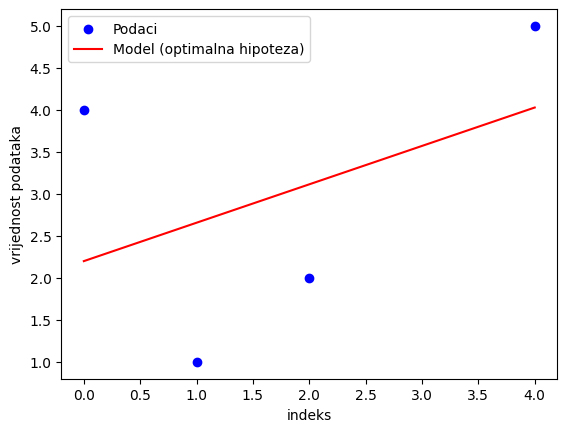

Srednje kvadratno odstupanje (nase, djelimo s 2 radi matematicke optimizacije) : 4.085714285714285
Pravo srednje kvadratno odstupanje u podacima, djelimo sa N(4):  2.0428571428571427


In [6]:
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

# prikaz primjera iz D i optimlane hipoteze od prije
plt.scatter(X.reshape(4), y, c="blue")
optimal_hypothesis = lambda x, w: w[1]*x + w[0]
plt.plot(X.reshape(4), [optimal_hypothesis(x, w) for x in X.reshape(4)], c="red")
plt.legend(["Podaci", "Model (optimalna hipoteza)"])
plt.xlabel("indeks")
plt.ylabel("vrijednost podataka")
plt.show()

# pogreska učenja (empirijska pogreska) prema izrazu:
# srednje kvadratno odstupanje
mse = 1/2 * sum([(optimal_hypothesis(np.squeeze(x), w) - y[i])**2 for i, x in enumerate(X)])
print("Srednje kvadratno odstupanje (nase, djelimo s 2 radi matematicke optimizacije) :", mse)

# opet racunananje pogreske ali sa ugradenom mean_square_error metodom (Ona racuna pravi MSE, tj dijeli sa N a ne sa 2)
mse = mean_squared_error(y, [optimal_hypothesis(x, w) for x in X.reshape(4)])
print(f"Pravo srednje kvadratno odstupanje u podacima, djelimo sa N({X.shape[0]}): ", mse)


### (d)

Uvjerite se da za primjere iz $\mathcal{D}$ težine $\mathbf{w}$ ne možemo naći rješavanjem sustava $\mathbf{w}=\mathbf{\Phi}^{-1}\mathbf{y}$, već da nam doista treba pseudoinverz.

**Q:** Zašto je to slučaj? Bi li se problem mogao riješiti preslikavanjem primjera u višu dimenziju? Ako da, bi li to uvijek funkcioniralo, neovisno o skupu primjera $\mathcal{D}$? Pokažite na primjeru.

In [7]:
print("primjeri iz D:")
print("X:", X)
print("y:", y)
print()
print("Matrica dizajna Theta (zapravo i dalje u Ulaznom prostoru zbog transformacije):")
print("theta:")
print(theta)

# pokusaj trazenja optimalnih tezina samo pomocu inverza Thete
w = np.linalg.inv(theta) @ y # nije kvadratna bacit ce linAlgError, treba nam pseudoinverz
print(w)

primjeri iz D:
X: [[0]
 [1]
 [2]
 [4]]
y: [4 1 2 5]

Matrica dizajna Theta (zapravo i dalje u Ulaznom prostoru zbog transformacije):
theta:
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 4.]]


LinAlgError: Last 2 dimensions of the array must be square

### (e) 

Proučite klasu [`LinearRegression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) iz modula [`sklearn.linear_model`](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model). Provjerite jesu li težine koje izračunava ta funkcija (dostupne pomoću atributa `coef_` i `intercept_`) jednake onima koje ste izračunali gore. Ako nisu, prilagodite kôd tako da jest.

**NB:** Obratite pozornost na to kako klase [`LinearRegression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) i [`PolynomialFeatures`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) koriste pomak i osigurajte da ga ne dodajete više puta.

Izračunajte predikcije modela (metoda `predict`) i uvjerite se da je pogreška učenja identična onoj koju ste ranije izračunali.

In [21]:
from sklearn.linear_model import LinearRegression # klascina lin regresija, Ne model nego obicna lin reg

model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False) # stvarmao naš model linearne regresije, sa odgovarajucim argumentima, prije nego sto ga mozemo koristiti moramo ga prilagoditi podacima, tj fitait ga
# n_jobs broj procesora koji koristimo, None znaci 1 u pravilu, -1 sve
# positive forsira model da nuzno pronade pozitivne koeficijente

model.fit(X, y, sample_weight=None) # model moramo fitati podacima, tj ovdje se model prilagodava podacima, tj tu
                                    # se zapravo dešava učenje modela, tj pronalazneje optimalne hipoteze
                                    # ta optimalna hipoteza se onda cuva u modelu i nakon fitanja, mozemo
                                    # trazti model da radi razlcite stvair da radi, od predikcija nove vrijednosti
                                    # do toga da nam vrati neke atribute i slicno -> ! ali prvo je potrebno model
                                    # prilagodiit podacima
# sample_weight nam gvori koliko je svaki pojedinacni primjer bitan u odnosu na druge, None znaci svi su jednako bitni
print("Tezine treniranog modela (optimalne hipoteze) su:", model.coef_, "to je bez baisa, tj odsjecka tj w0")
# coef je su tezine bez biasa tj bez odsjecka w0
print("bias tj odsjecak na y os je:", model.intercept_)

# jos neki atirbuti
print(model.n_jobs)
print(model.singular_) # singularne vrijednosti, za SVD
print("Predkcija za novu vrijednost x = 3.5 je: ", model.predict([[3.5]]))
print(model.rank_) # vraca rang matrice, proširene ako smo odlucili trenirait model sa biasom, tj fit_intercept=True,
                   # ako smo ucili model bez baisa ond anam vraca samo rang matrice dizajna
print("broj ulaznih znacajki", model.n_features_in_)
# print("izmena pojedine znacajke (ako smo fitali sa pandas DF): ", model.feature_names_in_)

# pristup hiperparametrima i izmjena hiperparametera, tj argumenta za kreiranje modela
print("hiperparamteri modela: ", model.get_params())
# model.set_params() # samo mijenja postavke modela, ali se ne fita ponovno, mi ga moramo fitati ponovno ukoliko ga                     # zelimo trenirati na novim podacima ili slicno


Tezine treniranog modela (optimalne hipoteze) su: [0.45714286] to je bez baisa, tj odsjecka tj w0
bias tj odsjecak na y os je: 2.2
None
[2.95803989]
Predkcija za novu vrijednost x = 3.5 je:  [3.8]
1
broj ulaznih znacajki 1
hiperparamteri modela:  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}


In [22]:
print("predikcija modela: ", model.predict([[3.8], [4.2]]))
print("pogreska modela (mse): ", mean_squared_error(y, model.predict(X)))

predikcija modela:  [3.93714286 4.12      ]
pogreska modela (mse):  2.042857142857143


### 2. Polinomijalna regresija i utjecaj šuma

### (a)

Razmotrimo sada regresiju na većem broju primjera. Definirajte funkciju `make_labels(X, f, noise=0)` koja uzima matricu neoznačenih primjera $\mathbf{X}_{N\times n}$ te generira vektor njihovih oznaka $\mathbf{y}_{N\times 1}$. Oznake se generiraju kao $y^{(i)} = f(x^{(i)})+\mathcal{N}(0,\sigma^2)$, gdje je $f:\mathbb{R}^n\to\mathbb{R}$ stvarna funkcija koja je generirala podatke (koja nam je u stvarnosti nepoznata), a $\sigma$ je standardna devijacija Gaussovog šuma, definirana parametrom `noise`. Za generiranje šuma možete koristiti funkciju [`numpy.random.normal`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html). 

Generirajte skup za učenje od $N=50$ primjera uniformno distribuiranih u intervalu $[-5,5]$ pomoću funkcije $f(x) = 5 + x -2 x^2 -5 x^3$ uz šum  $\sigma=200$:

In [23]:
def make_labels(X, f, noise=0):
    return f(X) + np.random.normal(loc=0, scale=noise, size=f(X).shape)

In [24]:
def make_instances(x1, x2, N) :
    return np.array([np.array([x]) for x in np.linspace(x1,x2,N)])

In [25]:
def f(X: np.ndarray) -> np.ndarray:
    return 5 + X - 2 * (X **2) - 5 * (X**3)

X = make_instances(-5, 5, 50)
y = make_labels(X, f, noise=200)
print(X)
print(y)


[[-5.        ]
 [-4.79591837]
 [-4.59183673]
 [-4.3877551 ]
 [-4.18367347]
 [-3.97959184]
 [-3.7755102 ]
 [-3.57142857]
 [-3.36734694]
 [-3.16326531]
 [-2.95918367]
 [-2.75510204]
 [-2.55102041]
 [-2.34693878]
 [-2.14285714]
 [-1.93877551]
 [-1.73469388]
 [-1.53061224]
 [-1.32653061]
 [-1.12244898]
 [-0.91836735]
 [-0.71428571]
 [-0.51020408]
 [-0.30612245]
 [-0.10204082]
 [ 0.10204082]
 [ 0.30612245]
 [ 0.51020408]
 [ 0.71428571]
 [ 0.91836735]
 [ 1.12244898]
 [ 1.32653061]
 [ 1.53061224]
 [ 1.73469388]
 [ 1.93877551]
 [ 2.14285714]
 [ 2.34693878]
 [ 2.55102041]
 [ 2.75510204]
 [ 2.95918367]
 [ 3.16326531]
 [ 3.36734694]
 [ 3.57142857]
 [ 3.7755102 ]
 [ 3.97959184]
 [ 4.18367347]
 [ 4.3877551 ]
 [ 4.59183673]
 [ 4.79591837]
 [ 5.        ]]
[[ 353.74144158]
 [ 215.63492524]
 [ 575.64442888]
 [ 334.11227809]
 [ 224.00472869]
 [ 301.36495513]
 [ 375.85737476]
 [ 329.77622353]
 [ 269.32801469]
 [ 164.37765886]
 [ 147.66140317]
 [  14.18871916]
 [  14.5051977 ]
 [-207.47118332]
 [  79.7466

Prikažite taj skup funkcijom [`scatter`](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.scatter).

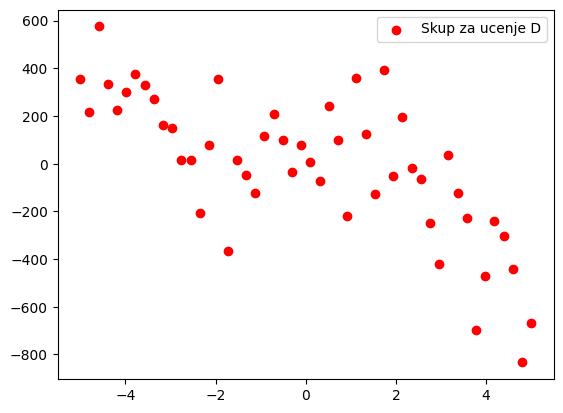

In [26]:
plt.scatter(X, y, c="r")
plt.legend(["Skup za ucenje D"])
plt.show()

### (b)

Trenirajte model polinomijalne regresije stupnja $d=3$. Na istom grafikonu prikažite naučeni model $h(\mathbf{x})=\mathbf{w}^\intercal\tilde{\mathbf{x}}$ i primjere za učenje. Izračunajte pogrešku učenja modela.

tezine, tj paramteri, bez w0 [[ 8.78458494 -7.23430908 -5.22755245]]
odsječak tj. bias, w0:  [57.12797428]
pogreska ucenja modela, mse:  30162.664687254102


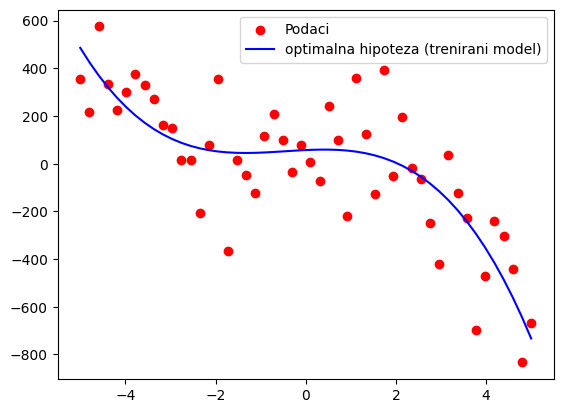

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

poly = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)
theta = poly.fit_transform(X)
model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False)
model.fit(theta, y, sample_weight=None)
print("tezine, tj paramteri, bez w0", model.coef_)
print("odsječak tj. bias, w0: ", model.intercept_)

plt.scatter(X, y, c="r")
plt.plot(X, model.predict(theta), c="b")
plt.legend(["Podaci", "optimalna hipoteza (trenirani model)"])
print("pogreska ucenja modela, mse: ", mean_squared_error(y, model.predict(theta))) # prava pogreska optimal hipoteze

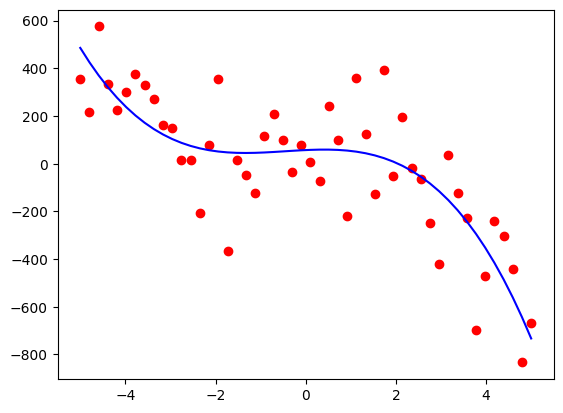

In [28]:
# ono kako smo ovo urednije mogli napraviti
from sklearn.pipeline import Pipeline

# Pipline funckionira na nacin da mu damo listu tuplova, di je svaki tuple (ime dijela piplina, konkretan objekt koji korstimo, npr transformator, model i slicno)
# pipline funkcionira tako da mi kad nad cijelim piplinom pozovmeo npr .fit() on interno pozove fit nad prvim objetkom
# dobije rezultat pa .fit nad drugim objektom i tako rezltat ide dalje dok se svugdje ne pozove fit.
# ukoliko se pozove predict, onda svi objekti osim zadnjrg zovu .transform jedna iza drugog i output se pipa
# a zadnja komponenta koji je u pravilu model ce zvati .predict(), s time svime upravlja pipline
# DA bi se nesot moglo stvaiti u pipline mora na svim mjestima osim zadnjeg imati implementiranu metodu .fit i .transform, a zadnji korak mora imati metode .fit i .predcit (obicno model)
model = Pipeline([
     ("poly", PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)),
     ("reg", LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False))
     ]
)
model.fit(X, y)

plt.scatter(X, y, c="r")
plt.plot(X, model.predict(X), c="b")
plt.show()


## Odnos između `PolynomialFeatures(include_bias)` i `LinearRegression(fit_intercept)`

Oba mehanizma mogu dodati bias (presjek). Potrebno je uključiti samo jedan, jer ako su oba aktivna, bias se duplicira i uzrokuje multikolinearnost.

### 4 kombinacije

| `include_bias` | `fit_intercept` | Što se događa | Preporuka                                                                                              |
|----------------:|----------------:|---------------|--------------------------------------------------------------------------------------------------------|
| True | False | Bias je već uključen kao stupac 1 u značajkama. | Ispravno                                                                                               |
| False | True | Linearni model sam trenira bias. | Najčešće i preporučeno                                                                                 |
| True | True | Bias se pojavljuje dvaput → multikolinearnost. | Izbjegavati ; ali izgleda da ce model sam nauciti ignorirati tu 1. znacajku onda, svejendo izbjegavati |
| False | False | Model bez bias termina (prolazi kroz ishodište). | Samo ako je to namjerno                                                                                |

### Zaključak

Najčešće se koristi:
```python
PolynomialFeatures(degree=d, include_bias=False)
LinearRegression(fit_intercept=True)
```
Time se bias uči unutar modela, dok PolynomialFeatures samo generira nelinearne značajke (x, x², x³, ...).



### 3. Odabir modela

### (a)

Na skupu podataka iz zadatka 2 trenirajte pet modela linearne regresije $\mathcal{H}_d$ različite složenosti, gdje je $d$ stupanj polinoma, $d\in\{1,3,5,10,20\}$. Prikažite na istome grafikonu skup za učenje i funkcije $h_d(\mathbf{x})$ za svih pet modela (preporučujemo koristiti `plot` unutar `for` petlje). Izračunajte pogrešku učenja svakog od modela.

**Q:** Koji model ima najmanju pogrešku učenja i zašto?

Srednje kvadratna odstupanja, tj pogreska učenja je redom:
['d : 1', 'd : 3', 'd : 5', 'd : 10', 'd : 20']
[44264.45752566412, 30162.664687254102, 27778.79883416578, 26386.605378662407, 18841.64615697051]


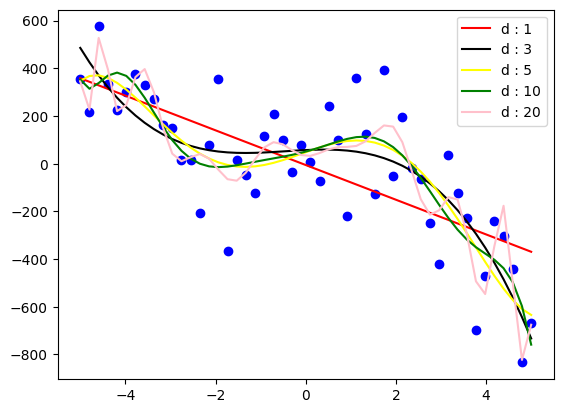

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

mse_errors = []
poly_names = []
for d, c in zip({1, 3, 5, 10, 20}, ["red", "black", "yellow", "green", "pink"]):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, interaction_only=False, include_bias=False)),
        ("reg", LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False))
    ])
    model.fit(X, y)
    plt.plot(X, model.predict(X), c=c)
    poly_names.append(f"d : {d}")
    mse_errors.append(mean_squared_error(model.predict(X), y))

plt.scatter(X, y, c="blue")
plt.legend(poly_names)
print("Srednje kvadratna odstupanja, tj pogreska učenja je redom:")
print(poly_names)
print(mse_errors)
plt.show()


### (b)

Razdvojite skup primjera iz zadatka 2 pomoću funkcije [`model_selection.train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) na skup za učenja i skup za ispitivanje u omjeru 1:1. Prikažite na jednom grafikonu pogrešku učenja i ispitnu pogrešku za modele polinomijalne regresije $\mathcal{H}_d$, sa stupnjem polinoma $d$ u rasponu $d\in [1,2,\ldots,20]$. Budući da kvadratna pogreška brzo raste za veće stupnjeve polinoma, umjesto da iscrtate izravno iznose pogrešaka, iscrtajte njihove logaritme.

**NB:** Podjela na skupa za učenje i skup za ispitivanje mora za svih dvadeset modela biti identična.

**Q:** Je li rezultat u skladu s očekivanjima? Koji biste model odabrali i zašto?

**Q:** Pokrenite iscrtavanje više puta. U čemu je problem? Bi li problem bio jednako izražen kad bismo imali više primjera? Zašto?

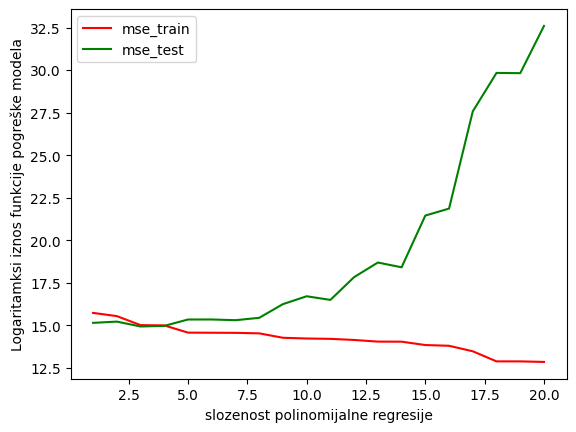

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, train_size=0.5, shuffle=True, stratify=None) # vraca se tuple numpy ndarray
# stratify-u se kao argument preda skup ciljnih vrijednosti y, on osigurava da jedank udio pojedinih klasa bude i u
# train i u test skupu; !! to je nuzno da se koristi kod klasifikacije, pogotvo kod ne balansiranog dataseta
# kod regresije se to nemora koristiti

X_train_3b_copy, X_test_3b_copy, y_train_3b_copy, y_test_3b_copy = X_train, X_test, y_train, y_test

mse_train = []
mse_test = []
for d in range(1, 21, 1):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=False)),
        ("reg", LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False))
    ])
    model.fit(X_train, y_train)
    mse_train.append(mean_squared_error(y_train, model.predict(X_train)))
    mse_test.append(mean_squared_error(y_test, model.predict(X_test)))

plt.plot(range(1, 21, 1), np.log2(mse_train), c="r")
plt.plot(range(1, 21, 1), np.log2(mse_test), c="g")
plt.xlabel("slozenost polinomijalne regresije")
plt.ylabel("Logaritamksi iznos funkcije pogreške modela")
plt.legend(["mse_train", "mse_test"])
plt.show()


### (c)

Točnost modela ovisi o (1) njegovoj složenosti (stupanj $d$ polinoma), (2) broju primjera $N$, i (3) količini šuma. Kako biste to analizirali, nacrtajte grafikone pogrešaka kao u 3b, ali za različit $N\in$ (trećina, dvije trećine, sve) i količine šuma $\sigma\in\{100,200,500\}$ (ukupno 9 grafikona). Upotrijebite funkciju [`subplots`](http://matplotlib.org/examples/pylab_examples/subplots_demo.html) kako biste pregledno posložili grafikone u tablicu $3\times 3$. Podatci se generiraju na isti način kao u zadatku 2.

**NB:** Pobrinite se da svi grafikoni budu generirani nad usporedivim skupovima podataka, na sljedeći način. Generirajte najprije svih 1000 primjera, podijelite ih na skupove za učenje i skupove za ispitivanje (dva skupa od po 500 primjera). Zatim i od skupa za učenje i od skupa za ispitivanje načinite tri različite verzije, svaka s drugačijom količinom šuma (ukupno 2x3=6 verzija podataka). Kako bi simulirali veličinu skupa podataka, od tih dobivenih 6 skupova podataka uzorkujte trećinu, dvije trećine i sve podatke. Time ste dobili 18 skupova podataka -- skup za učenje i za testiranje za svaki od devet grafova.

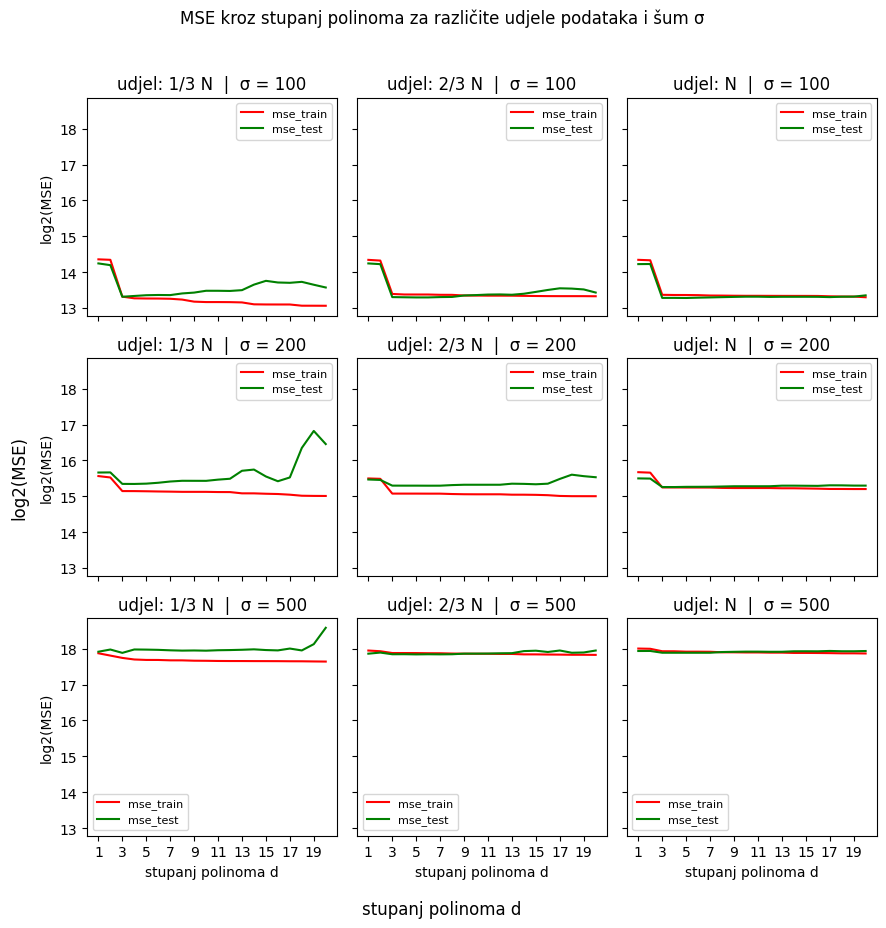

In [31]:
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

N = 1000
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(9, 9), sharex=True, sharey=True)

X_all = make_instances(-5, 5, N)
X_train, X_test = train_test_split(X_all, train_size=0.5, test_size=0.5, random_state=42, shuffle=True, stratify=None)
y_train = []
y_test = []

sigmas = [100, 200, 500]
for std in sigmas:
    y_train.append(make_labels(X_train, f, noise=std))
    y_test.append(make_labels(X_test, f, noise=std))

frac_labels = ["1/3 N", "2/3 N", "N"]

all_train_data = []
all_test_data = []
for y_tr in y_train:
    for i in range(1, 3, 1):
        # za 1/3 N i 2/3N
        X_train_end, _, y_train_end, _ = train_test_split(X_train, y_tr, train_size=(i/3), random_state=42)
        all_train_data.append((X_train_end, y_train_end))
    # za cijeli N
    all_train_data.append((X_train, y_tr))

for y_tes in y_test:
    for i in range(1, 3, 1):
        _, X_test_end, _, y_test_end = train_test_split(X_test, y_tes, test_size=(i/3), random_state=42)
        all_test_data.append((X_test_end, y_test_end))
    all_test_data.append((X_test, y_tes))

for i in range(9):
    mse_train = []
    mse_test = []
    for d in range(1, 21, 1):
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=False)),
            ("reg", LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False))
        ])
        model.fit(all_train_data[i][0], all_train_data[i][1])
        mse_train.append(mean_squared_error(all_train_data[i][1], model.predict(all_train_data[i][0])))
        mse_test.append(mean_squared_error(all_test_data[i][1], model.predict(all_test_data[i][0])))
    c = i % 3
    r = i // 3
    ax[r][c].plot(range(1, 21, 1), np.log2(mse_train), c="r")
    ax[r][c].plot(range(1, 21, 1), np.log2(mse_test), c="g")
    ax[r][c].legend(["mse_train", "mse_test"], fontsize=8)
    ax[r][c].set_xticks(range(1, 21, 2))

    ax[r][c].set_title(f"udjel: {frac_labels[c]}  |  σ = {sigmas[r]}")
    if c == 0:
        ax[r][c].set_ylabel("log2(MSE)")
    if r == 2:
        ax[r][c].set_xlabel("stupanj polinoma d")

fig.suptitle("MSE kroz stupanj polinoma za različite udjele podataka i šum σ", y=1.02, fontsize=12)
fig.supxlabel("stupanj polinoma d")
fig.supylabel("log2(MSE)")

plt.tight_layout()
plt.show()

***Q:*** Jesu li rezultati očekivani? Obrazložite.

### 4. Regularizirana regresija

### (a)

U gornjim eksperimentima nismo koristili **regularizaciju**. Vratimo se najprije na primjer iz zadatka 1. Na primjerima iz tog zadatka izračunajte težine $\mathbf{w}$ za polinomijalni regresijski model stupnja $d=3$ uz L2-regularizaciju (tzv. *ridge regression*), prema izrazu $\mathbf{w}=(\mathbf{\Phi}^\intercal\mathbf{\Phi}+\lambda\mathbf{I})^{-1}\mathbf{\Phi}^\intercal\mathbf{y}$. Napravite izračun težina za regularizacijske faktore $\lambda=0$, $\lambda=1$ i $\lambda=10$ te usporedite dobivene težine.

**Q:** Kojih je dimenzija matrica koju treba invertirati?

**Q:** Po čemu se razlikuju dobivene težine i je li ta razlika očekivana? Obrazložite.

In [32]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# primjeri iz zadatka 1:
X = np.array([[0],[1],[2],[4]])
y = np.array([4,1,2,5])

poly = PolynomialFeatures(degree=3, include_bias=True, interaction_only=False)
poly.fit(X, y)

theta = poly.transform(X)

for l in [0, 1, 10]:
    reg_matrix = np.identity(theta.shape[1]) * l
    reg_matrix[0][0] = 0 # jer w0 ne regulariziramo
    w = np.linalg.inv(theta.T @ theta + reg_matrix) @ theta.T @ y
    print(f"optimalne tezine za lambda={l} su: ", w)

optimalne tezine za lambda=0 su:  [ 4.         -5.91666667  3.375      -0.45833333]
optimalne tezine za lambda=1 su:  [ 3.05696145 -0.69079365 -0.2831746   0.1445805 ]
optimalne tezine za lambda=10 su:  [ 2.49444184 -0.15897295 -0.13423067  0.0815601 ]


### (b)

Proučite klasu [`Ridge`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge) iz modula [`sklearn.linear_model`](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model), koja implementira L2-regularizirani regresijski model. Parametar $\alpha$ odgovara parametru $\lambda$. Primijenite model na istim primjerima kao u prethodnom zadatku i ispišite težine $\mathbf{w}$ (atributi `coef_` i `intercept_`). Ponovno, pripazite na pomak.

**Q:** Jesu li težine identične onima iz zadatka 4a? Ako nisu, objasnite zašto je to tako i kako biste to popravili.

In [33]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

X = np.array([[0],[1],[2],[4]])
y = np.array([4,1,2,5])

for l in [0, 1, 10]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False, interaction_only=False)),
        ("ridge", Ridge(alpha=l, fit_intercept=True, copy_X=True, positive=False))
    ])
    model.fit(X, y)
    print(f"bias za ridge regression model sa l={l} je:", model.named_steps["ridge"].intercept_)
    print(f"a ostale tezine su redom: ", model.named_steps["ridge"].coef_)
    print()


bias za ridge regression model sa l=0 je: 3.999999999999986
a ostale tezine su redom:  [-5.91666667  3.375      -0.45833333]

bias za ridge regression model sa l=1 je: 3.0569614512471652
a ostale tezine su redom:  [-0.69079365 -0.2831746   0.1445805 ]

bias za ridge regression model sa l=10 je: 2.494441843122973
a ostale tezine su redom:  [-0.15897295 -0.13423067  0.0815601 ]



### (c)

Vratimo se na slučaj $N=50$ slučajno generiranih primjera iz zadatka 2. Trenirajte modele polinomijalne regresije $\mathcal{H}_{\lambda,d}$ za $\lambda\in\{0,100\}$ i $d\in\{2,10\}$ (ukupno četiri modela). Skicirajte pripadne funkcije $h(\mathbf{x})$ i primjere (na jednom grafikonu; preporučujemo koristiti `plot` unutar `for` petlje).

**Q:** Jesu li rezultati očekivani? Obrazložite.

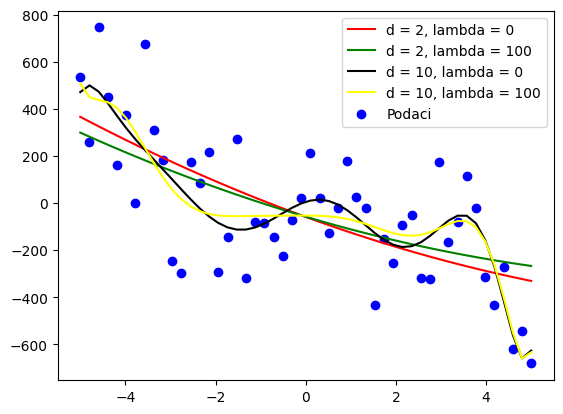

In [48]:
from matplotlib import pyplot as plt

def make_labels(X, f, noise=0):
    return f(X) + np.random.normal(loc=0, scale=noise, size=f(X).shape)

def make_instances(x1, x2, N):
    return np.array([np.array([x]) for x in np.linspace(x1, x2, N)])

def f(X: np.ndarray) -> np.ndarray:
    return 5 + X - 2 * (X ** 2) - 5 * (X ** 3)

X = make_instances(-5, 5, 50)
y = make_labels(X, f, noise=200)

lambdas = [0, 100]
degress = [2, 10]
colors = [["red", "black"], ["green", "yellow"]]
names = []
for j, d in enumerate(degress):
    for i, l in enumerate(lambdas):
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=False)),
            ("ridge", Ridge(alpha=l, fit_intercept=True, copy_X=True, positive=False))
        ])
        model.fit(X, y)
        plt.plot(X, model.predict(X), c=colors[i][j])
        names.append(f"d = {d}, lambda = {l}")

plt.scatter(X, y, c="blue")
names.append("Podaci")
plt.legend(names)
plt.show()




### (d)

Kao u zadataku 3b, razdvojite primjere na skup za učenje i skup za ispitivanje u omjeru 1:1. Prikažite krivulje logaritama pogreške učenja i ispitne pogreške u ovisnosti za model $\mathcal{H}_{d=10,\lambda}$, podešavajući faktor regularizacije $\lambda$ u rasponu $\lambda\in\{0,1,\dots,50\}$.

**Q:** Kojoj strani na grafikonu odgovara područje prenaučenosti, a kojoj podnaučenosti? Zašto?

**Q:** Koju biste vrijednosti za $\lambda$ izabrali na temelju ovih grafikona i zašto?


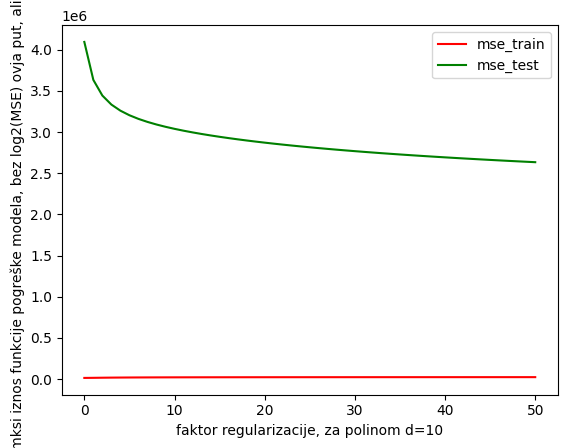

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, train_size=0.5, random_state=None, shuffle=True, stratify=None) # vraca se tuple numpy ndarray

mse_train = []
mse_test = []
d = 10
for l in range(0, 51, 1):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=False)),
        ("ridge", Ridge(alpha=l, fit_intercept=True, copy_X=True, positive=False))
    ])
    model.fit(X_train, y_train)
    mse_train.append(mean_squared_error(y_train, model.predict(X_train)))
    mse_test.append(mean_squared_error(y_test, model.predict(X_test)))

# stavio sam bez loga jer se ljepse vidi
plt.plot(range(0, 51, 1), (np.array(mse_train)), c="r")
plt.plot(range(0, 51, 1), (np.array(mse_test)), c="g")
plt.xlabel("faktor regularizacije, za polinom d=10")
plt.ylabel("Logaritamksi iznos funkcije pogreške modela, bez log2(MSE) ovja put, ali lako dodam")
plt.legend(["mse_train", "mse_test"])
plt.show()


    ### 5. L1-regularizacija i L2-regularizacija

Svrha regularizacije jest potiskivanje težina modela $\mathbf{w}$ prema nuli, kako bi model bio što jednostavniji. Složenost modela može se okarakterizirati normom pripadnog vektora težina $\mathbf{w}$, i to tipično L2-normom ili L1-normom. Za jednom trenirani model možemo izračunati i broj ne-nul značajki, ili L0-normu, pomoću sljedeće funkcije koja prima vektor težina $\mathbf{w}$:

In [36]:
def nonzeroes(coef, tol=1e-6): 
    return len(coef) - len(coef[np.isclose(0, coef, atol=tol)])

### (a)

Za ovaj zadatak upotrijebite skup za učenje i skup za testiranje iz zadatka 3b. Trenirajte modele **L2-regularizirane** polinomijalne regresije stupnja $d=5$, mijenjajući hiperparametar $\lambda$ u rasponu $\{1,2,\dots,100\}$. Za svaki od treniranih modela izračunajte L{0,1,2}-norme vektora težina $\mathbf{w}$ te ih prikažite kao funkciju od $\lambda$. Pripazite što točno šaljete u funkciju za izračun normi.

**Q:** Objasnite oblik obiju krivulja. Hoće li krivulja za $\|\mathbf{w}\|_2$ doseći nulu? Zašto? Je li to problem? Zašto?

**Q:** Za $\lambda=100$, koliki je postotak težina modela jednak nuli, odnosno koliko je model rijedak?

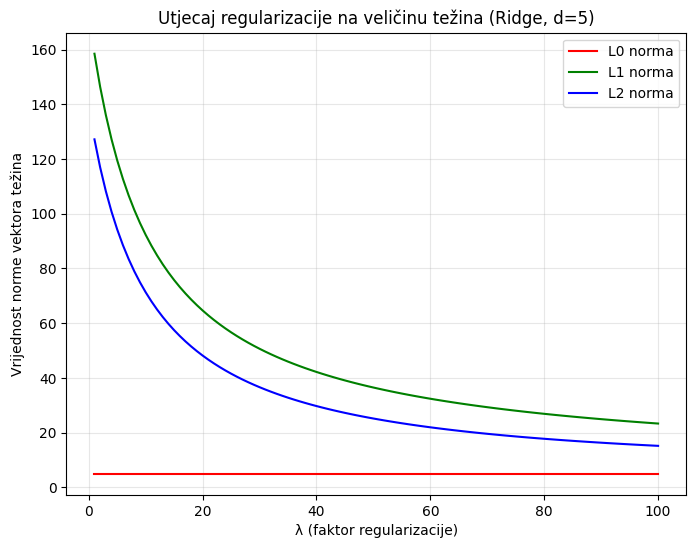

In [37]:
from math import sqrt
from matplotlib import pyplot as plt

X_train, _, y_train, _ = X_train_3b_copy, X_test_3b_copy, y_train_3b_copy, y_test_3b_copy

d = 5
lambdas = range(1, 101, 1)
l0, l1, l2 = [], [], []
for l in lambdas:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=False)),
        ("ridge", Ridge(alpha=l, fit_intercept=True, copy_X=True, positive=False))
    ])
    model.fit(X_train, y_train)
    coef = model.named_steps["ridge"].coef_.ravel()
    l0.append(nonzeroes(coef))
    l1.append(np.linalg.norm(coef, 1))
    l2.append(np.linalg.norm(coef, 2)) # ovo je L2 norma, ali u nasem regularizacijskom izrazu bi mi jos to kvadrirali

plt.figure(figsize=(8,6))
plt.plot(lambdas, l0, 'r', label='L0 norma')
plt.plot(lambdas, l1, 'g', label='L1 norma')
plt.plot(lambdas, l2, 'b', label='L2 norma')
plt.legend()
plt.xlabel("λ (faktor regularizacije)")
plt.ylabel("Vrijednost norme vektora težina")
plt.title("Utjecaj regularizacije na veličinu težina (Ridge, d=5)")
plt.grid(True, alpha=0.3)
plt.show()

### (b)

Glavna prednost L1-regularizirane regresije (ili *LASSO regression*) nad L2-regulariziranom regresijom jest u tome što L1-regularizirana regresija rezultira **rijetkim modelima** (engl. *sparse models*), odnosno modelima kod kojih su mnoge težine pritegnute na nulu. Pokažite da je to doista tako, ponovivši gornji eksperiment s **L1-regulariziranom** regresijom, implementiranom u klasi  [`Lasso`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) u modulu [`sklearn.linear_model`](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model).

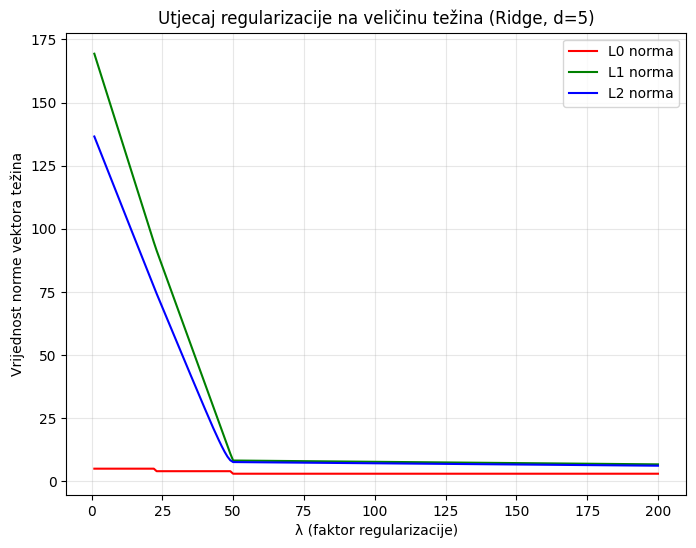

In [38]:
from sklearn.linear_model import Lasso
from math import sqrt
from matplotlib import pyplot as plt

X_train, _, y_train, _ = X_train_3b_copy, X_test_3b_copy, y_train_3b_copy, y_test_3b_copy

d = 5
lambdas = range(1, 201, 1)
l0, l1, l2 = [], [], []
for l in lambdas:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=False)),
        ("ridge", Lasso(alpha=l, fit_intercept=True, copy_X=True, positive=False, max_iter=100_000_000))
    ])
    model.fit(X_train, y_train)
    coef = model.named_steps["ridge"].coef_.ravel()
    l0.append(nonzeroes(coef))
    l1.append(np.linalg.norm(coef, 1))
    l2.append(np.linalg.norm(coef, 2)) # ovo je L2 norma, ali u nasem regularizacijskom izrazu bi mi jos to kvadrirali

plt.figure(figsize=(8,6))
plt.plot(lambdas, l0, 'r', label='L0 norma')
plt.plot(lambdas, l1, 'g', label='L1 norma')
plt.plot(lambdas, l2, 'b', label='L2 norma')
plt.legend()
plt.xlabel("λ (faktor regularizacije)")
plt.ylabel("Vrijednost norme vektora težina")
plt.title("Utjecaj regularizacije na veličinu težina (Ridge, d=5)")
plt.grid(True, alpha=0.3)
plt.show()

### 6. Značajke različitih skala

Često se u praksi možemo susreti sa podatcima u kojima sve značajke nisu jednakih magnituda. Primjer jednog takvog skupa je regresijski skup podataka `grades` u kojem se predviđa prosjek ocjena studenta na studiju (1--5) na temelju dvije značajke: bodova na prijamnom ispitu (1--3000) i prosjeka ocjena u srednjoj školi. Prosjek ocjena na studiju izračunat je kao težinska suma ove dvije značajke uz dodani šum.

Koristite sljedeći kôd kako biste generirali ovaj skup podataka.

In [39]:
n_data_points = 500
np.random.seed(69)

# Generiraj podatke o bodovima na prijamnom ispitu koristeći normalnu razdiobu i ograniči ih na interval [1, 3000].
exam_score = np.random.normal(loc=1500.0, scale = 500.0, size = n_data_points) 
exam_score = np.round(exam_score)
exam_score[exam_score > 3000] = 3000
exam_score[exam_score < 0] = 0

# Generiraj podatke o ocjenama iz srednje škole koristeći normalnu razdiobu i ograniči ih na interval [1, 5].
grade_in_highschool = np.random.normal(loc=3, scale = 2.0, size = n_data_points)
grade_in_highschool[grade_in_highschool > 5] = 5
grade_in_highschool[grade_in_highschool < 1] = 1

# Matrica dizajna.
grades_X = np.array([exam_score,grade_in_highschool]).T

# Završno, generiraj izlazne vrijednosti.
rand_noise = np.random.normal(loc=0.0, scale = 0.5, size = n_data_points)
exam_influence = 0.9
grades_y = ((exam_score / 3000.0) * (exam_influence) + (grade_in_highschool / 5.0) \
            * (1.0 - exam_influence)) * 5.0 + rand_noise
grades_y[grades_y < 1] = 1
grades_y[grades_y > 5] = 5

### a)

Iscrtajte ovisnost ciljne vrijednosti (y-os) o prvoj i o drugoj značajki (x-os). Iscrtajte dva odvojena grafa.

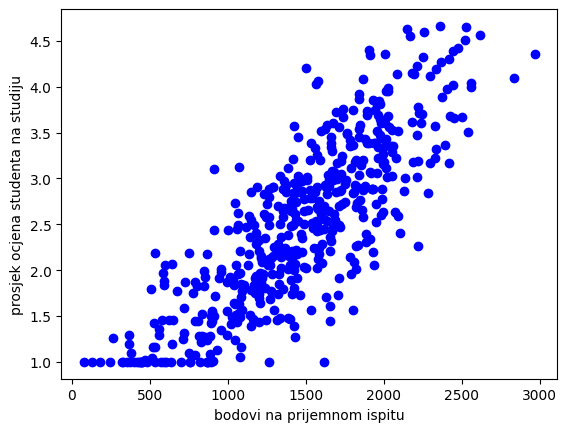

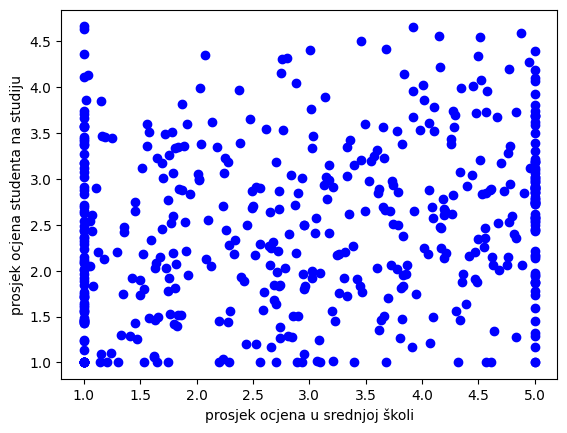

In [40]:
from matplotlib import pyplot as plt

plt.scatter(exam_score, grades_y, c="blue")
plt.xlabel("bodovi na prijemnom ispitu")
plt.ylabel("prosjek ocjena studenta na studiju")
plt.show()

plt.scatter(grade_in_highschool, grades_y, c="blue")
plt.xlabel("prosjek ocjena u srednjoj školi")
plt.ylabel("prosjek ocjena studenta na studiju")
plt.show()


### b)

Naučite model L2-regularizirane regresije ($\lambda = 0.01$), na podacima `grades_X` i `grades_y`:

[0.00141497 0.09477276]


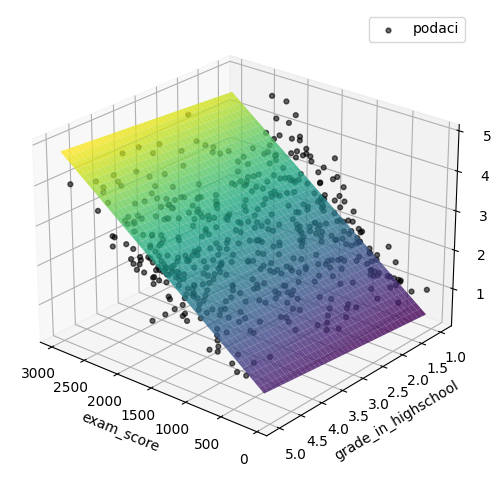

In [41]:
model = Pipeline([
    ("ridge", Ridge(alpha=0.01, fit_intercept=True, positive=False))
])
model.fit(grades_X, grades_y)
print(model.named_steps["ridge"].coef_)

# pokušaj vizualizacije u 3D:
x = np.linspace(grades_X[:,0].min(), grades_X[:,0].max(), 40)
y = np.linspace(grades_X[:,1].min(), grades_X[:,1].max(), 40)
Xg, Yg = np.meshgrid(x, y)
Zg = model.predict(np.c_[Xg.ravel(), Yg.ravel()]).reshape(Xg.shape)

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(grades_X[:,0], grades_X[:,1], grades_y, s=12, alpha=0.6, c='k', label="podaci")
ax.plot_surface(Xg, Yg, Zg, cmap='viridis', alpha=0.8)

ax.set_xlabel("exam_score"); ax.set_ylabel("grade_in_highschool"); ax.set_zlabel("y")
ax.view_init(elev=25, azim=130); ax.legend()
plt.show()

Sada ponovite gornji eksperiment, ali prvo skalirajte podatke `grades_X` i `grades_y` i spremite ih u varijable `grades_X_fixed` i `grades_y_fixed`. Za tu svrhu, koristite [`StandardScaler`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [42]:
from sklearn.preprocessing import StandardScaler

# std_scalar = StandardScaler(copy=True, with_mean=True, with_std=True)
# Standard scaler je transformer objekt koji ce proci po svakoj znacajci posebno, na temelju podataka iz
# trian data za pojedinu znacajku ce izracuntait mean i std, i onda ce ubuduce kada se pozove .transform()
# nad njim koristiit taj mean i std te znacajke, da prode po vrijednostima znacajki primjera i od svake te vrijednosti
# ce oduzeti mean i pdoijeliti sa std, da se normlaizira
# to se mora raditi za veicnu algoritama strojnog ucenja, i to osigurava da ti algoritmi dobro rade
# y se u pravilu ne skalira, ali moze
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler() # u pravilu ne zelimo skalirat y, ali poneka di to treba

grades_X_fixed = scaler_X.fit_transform(grades_X)
grades_y_fixed = scaler_y.fit_transform(grades_y.reshape(-1, 1)).ravel()

# ponavljanje eksperimenta:
model = Pipeline([
    ("ridge", Ridge(alpha=0.01, fit_intercept=True, positive=False))
])
model.fit(grades_X_fixed, grades_y_fixed)
print(model.named_steps["ridge"].coef_)


[0.81630375 0.15167761]


B**Q:** Gledajući grafikone iz podzadatka (a), koja značajka bi trebala imati veću magnitudu, odnosno važnost pri predikciji prosjeka na studiju? Odgovaraju li težine Vašoj intuiciji? Objasnite.

[0.73954683 0.13741539]


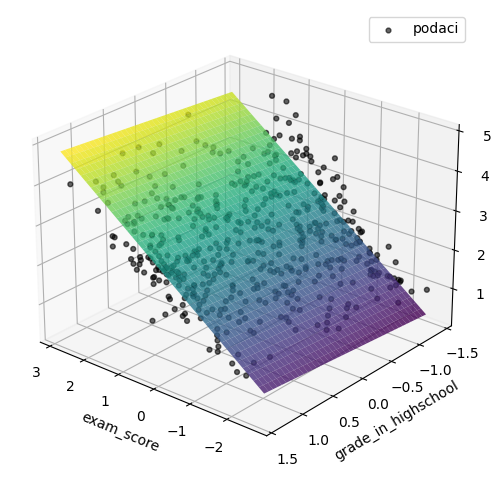

In [70]:
# NESTo MOJE DODATNO
# standardssclaerm nuzno u prvailu smao radi sa matricom dizajna, X tj Theta, y u pravilu ne zelimo sclairat,
# kada ga stavimo u pipline takoder samo transofmrira X

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ("scaler", StandardScaler(copy=True, with_mean=True, with_std=True)),
    ("ridge", Ridge(alpha=0.01, fit_intercept=True))
])

model.fit(grades_X, grades_y)
print(model.named_steps["ridge"].coef_) # razlicto je jer sma tamo gore sclairoa i y i x

# pokušaj vizualizacije u 3D:
scaled_X =  model.named_steps["scaler"].transform(grades_X)
x = np.linspace(scaled_X[:,0].min(), scaled_X[:,0].max(), 40)
y = np.linspace(scaled_X[:,1].min(), scaled_X[:,1].max(), 40)
Xg, Yg = np.meshgrid(x, y)

# xg i Yg su vec sklairnia pa je ovdje krivo opet krositi cijeli pipline jer ce se 2 puta sklairati
# Zg = model.predict(np.c_[Xg.ravel(), Yg.ravel()]).reshape(Xg.shape)
# trebamo ovako:
Zg = model.named_steps["ridge"].predict(np.c_[Xg.ravel(), Yg.ravel()]).reshape(Xg.shape)

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(scaled_X[:,0], scaled_X[:,1], grades_y, s=12, alpha=0.6, c='k', label="podaci")
ax.plot_surface(Xg, Yg, Zg, cmap='viridis', alpha=0.8)

ax.set_xlabel("exam_score"); ax.set_ylabel("grade_in_highschool"); ax.set_zlabel("y")
ax.view_init(elev=25, azim=130); ax.legend()
plt.show()

### 7. Multikolinearnost

### a)

Izradite skup podataka `grades_X_fixed_colinear` tako što ćete u skupu `grades_X_fixed` iz
zadatka *7b* duplicirati zadnji stupac (ocjenu iz srednje škole). Time smo efektivno uveli savršenu multikolinearnost.

In [107]:
grades_X_fixed_colinear = np.c_[grades_X_fixed, grades_X_fixed[:, -1]]
print(grades_X_fixed_colinear)


[[ 0.95063817 -0.78607869 -0.78607869]
 [-0.50343434 -0.50193004 -0.50193004]
 [ 1.18596832 -0.52213172 -0.52213172]
 ...
 [-0.31593552  0.80074234  0.80074234]
 [ 0.81288393  1.24783236  1.24783236]
 [-0.01938126  1.21729714  1.21729714]]


Ponovno, naučite na ovom skupu L2-regularizirani model regresije ($\lambda = 0.01$).

In [108]:
# L2 regularizirnai model regresije (skalirlai smo podatke, ali duplicirali smo zadnji redak, uveli multikolinearnost:
model = Ridge(alpha=0.01, fit_intercept=True, positive=False)
model.fit(grades_X_fixed_colinear, grades_y_fixed)
model.coef_

array([0.81630364, 0.07583957, 0.07583957])

**Q:** Usporedite iznose težina s onima koje ste dobili u zadatku *7b*. Što se dogodilo?

### b)

Slučajno uzorkujte 50% elemenata iz skupa `grades_X_fixed_colinear` i naučite dva modela L2-regularizirane regresije, jedan s $\lambda=0.01$ i jedan s $\lambda=1000$). Ponovite ovaj pokus 10 puta (svaki put s drugim podskupom od 50% elemenata).  Za svaki model, ispišite dobiveni vektor težina u svih 10 ponavljanja te ispišite standardnu devijaciju vrijednosti svake od težina (ukupno šest standardnih devijacija, svaka dobivena nad 10 vrijednosti).

In [109]:
weights_001 = []
weights_1000 = []
for i in range(10):
    grades_X_50, _, grades_y_50, _ = train_test_split(grades_X_fixed_colinear, grades_y_fixed, train_size=0.5, shuffle=True)
    model_001 = Ridge(alpha=0.01, fit_intercept=True, positive=False)
    model_1000 = Ridge(alpha=1000, fit_intercept=True, positive=False)
    model_001.fit(grades_X_50, grades_y_50)
    model_1000.fit(grades_X_50, grades_y_50)
    weights_001.append(model_001.coef_.ravel())
    weights_1000.append(model_1000.coef_.ravel())

weights_001 = np.array(weights_001)
weights_1000 = np.array(weights_1000)

print("Težine kroz 10 ponavljanja za l = 0.01:")
print(weights_001)
print("\nStandardne devijacije po težini (w1, w2, w3):")
print(np.std(weights_001, axis=0, ddof=1))

print("\nTežine kroz 10 ponavljanja za l = 1000:")
print(weights_1000)
print("\nStandardne devijacije po težini (w1, w2, w3):")
print(np.std(weights_1000, axis=0, ddof=1))

Težine kroz 10 ponavljanja za l = 0.01:
[[0.79950862 0.08467233 0.08467233]
 [0.82987769 0.07537179 0.07537179]
 [0.81557947 0.06494756 0.06494756]
 [0.79593687 0.09828475 0.09828475]
 [0.80219494 0.076076   0.076076  ]
 [0.75537781 0.07005015 0.07005015]
 [0.80343597 0.06992097 0.06992097]
 [0.80772898 0.08630553 0.08630553]
 [0.79612448 0.07506196 0.07506196]
 [0.83302625 0.08047519 0.08047519]]

Standardne devijacije po težini (w1, w2, w3):
[0.02153789 0.00971277 0.00971277]

Težine kroz 10 ponavljanja za l = 1000:
[[0.17032849 0.0371663  0.0371663 ]
 [0.17285094 0.0387298  0.0387298 ]
 [0.1646985  0.02700149 0.02700149]
 [0.17276198 0.04464644 0.04464644]
 [0.15362785 0.03268139 0.03268139]
 [0.15864655 0.03105603 0.03105603]
 [0.18117546 0.03927707 0.03927707]
 [0.16794381 0.0342185  0.0342185 ]
 [0.14961402 0.02947305 0.02947305]
 [0.15437928 0.03071688 0.03071688]]

Standardne devijacije po težini (w1, w2, w3):
[0.01021068 0.0053937  0.0053937 ]


**Q:** Kako regularizacija utječe na stabilnost težina?  
**Q:** Jesu li koeficijenti jednakih magnituda kao u prethodnom pokusu? Objasnite zašto.